In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset

In [2]:

df = pd.read_csv("/content/sample_data/archive (4).zip")
print(df.head())
print(df.info())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID         Cat

# Data Cleaning & Preprocessing

In [6]:
print(df.isnull().sum())
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df = df.drop_duplicates()
df = df.ffill()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64


# Remove Unnecessary Columns

In [7]:

df = df.drop(columns=['ID', 'Metadata'], errors='ignore')

# Descriptive Statistics

In [8]:

print(df.describe())
total_sales = df['Sales'].sum()
print("Total Sales:", total_sales)
avg_sales = df['Sales'].mean()
print("Average Sales:", avg_sales)
print("Max Sales:", df['Sales'].max())
print("Min Sales:", df['Sales'].min())

            Row ID                     Order Date   Postal Code         Sales
count  9800.000000                           9800   9800.000000   9800.000000
mean   4900.500000  2017-05-01 05:13:51.673469440  55295.655714    230.769059
min       1.000000            2015-01-03 00:00:00   1040.000000      0.444000
25%    2450.750000            2016-05-24 00:00:00  23223.000000     17.248000
50%    4900.500000            2017-06-26 00:00:00  59253.500000     54.490000
75%    7350.250000            2018-05-15 00:00:00  90008.000000    210.605000
max    9800.000000            2018-12-30 00:00:00  99301.000000  22638.480000
std    2829.160653                            NaN  32035.893637    626.651875
Total Sales: 2261536.7827000003
Average Sales: 230.7690594591837
Max Sales: 22638.48
Min Sales: 0.444


# Sales Trend Analysis

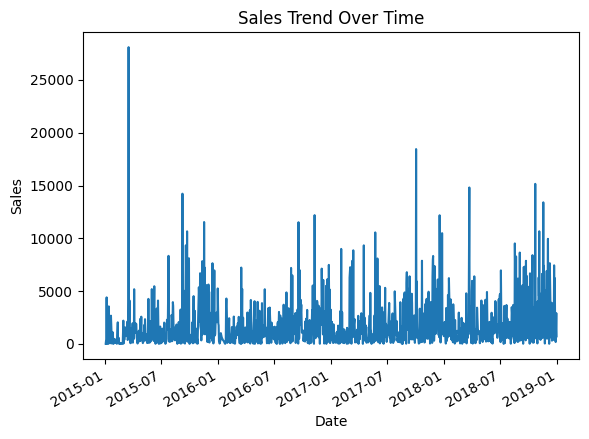

In [10]:
plt.figure()
df.groupby('Order Date')['Sales'].sum().plot()
plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

# Store / Product Analysis

Region
Central    492646.9132
East       669518.7260
South      389151.4590
West       710219.6845
Name: Sales, dtype: float64


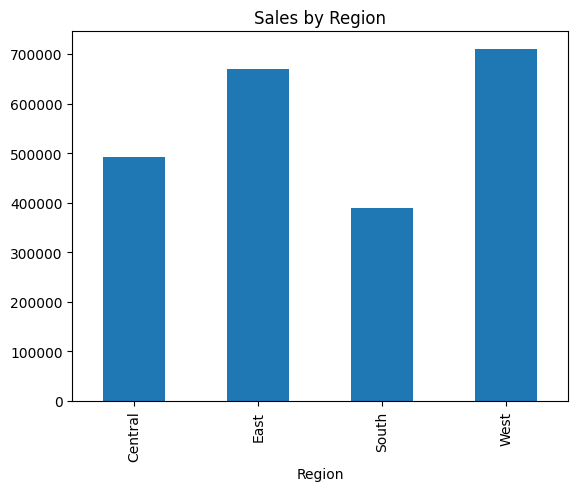

Category
Furniture          728658.5757
Office Supplies    705422.3340
Technology         827455.8730
Name: Sales, dtype: float64


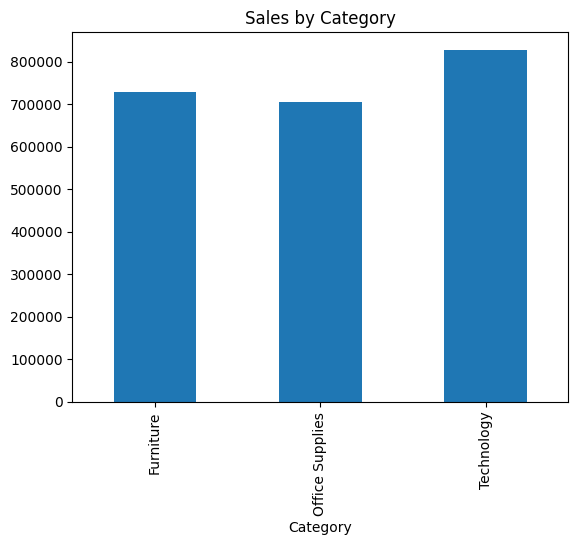

In [12]:
store_sales = df.groupby('Region')['Sales'].sum()
print(store_sales)
store_sales.plot(kind='bar')
plt.title("Sales by Region")
plt.show()
product_sales = df.groupby('Category')['Sales'].sum()
print(product_sales)
product_sales.plot(kind='bar')
plt.title("Sales by Category")
plt.show()

# Time-Based Analysis

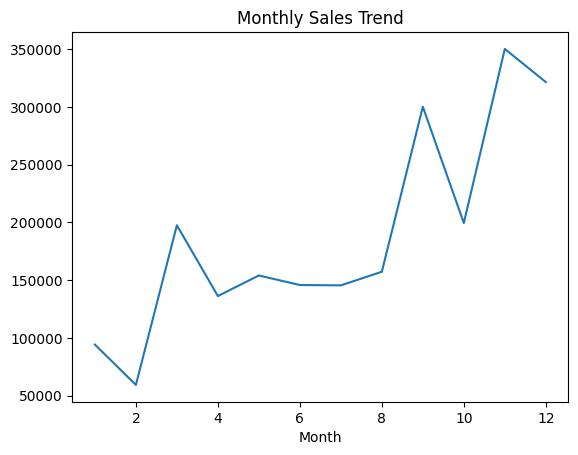

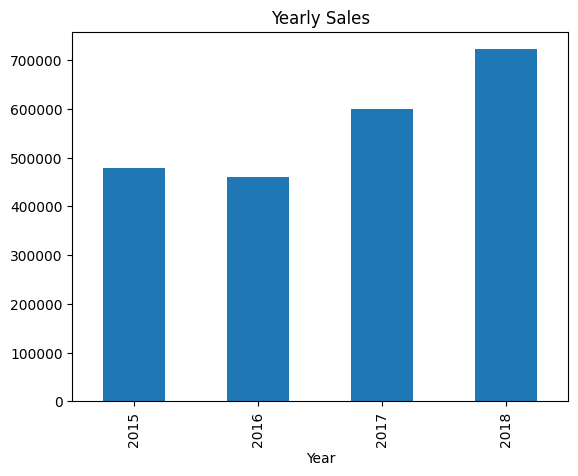

In [15]:

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Day'] = df['Order Date'].dt.day
df.groupby('Month')['Sales'].sum().plot()
plt.title("Monthly Sales Trend")
plt.show()
df.groupby('Year')['Sales'].sum().plot(kind='bar')
plt.title("Yearly Sales")
plt.show()


# Relationship Analysis

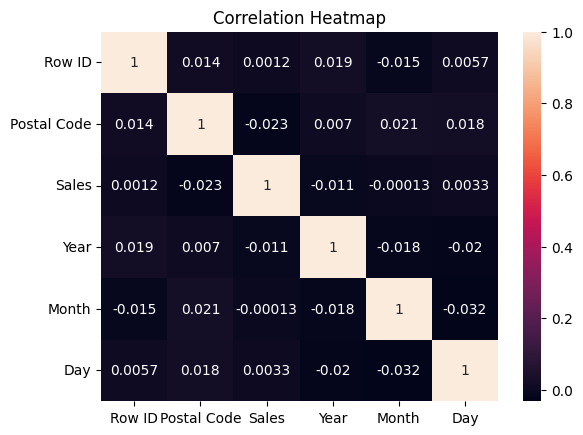

In [16]:

plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

# Histogram

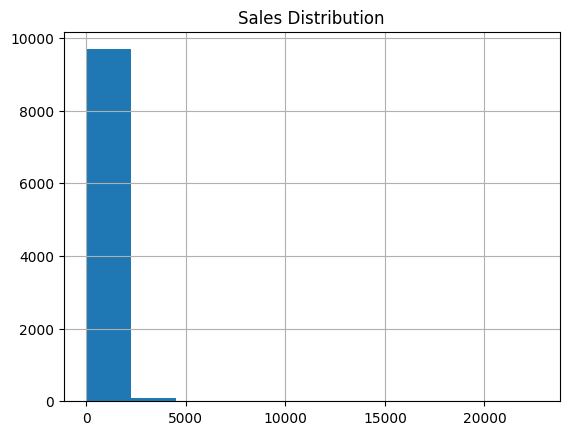

In [17]:
plt.figure()
df['Sales'].hist()
plt.title("Sales Distribution")
plt.show()

# Box plot

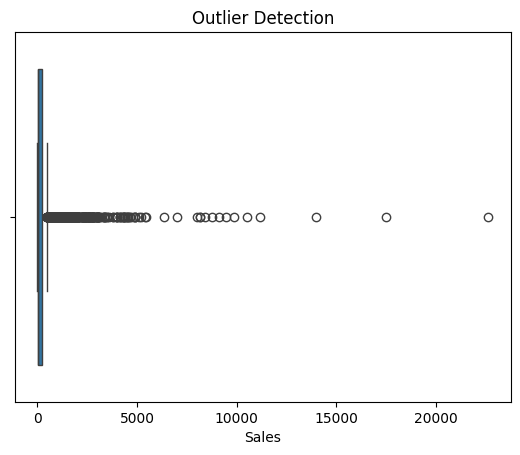

In [18]:
plt.figure()
sns.boxplot(x=df['Sales'])
plt.title("Outlier Detection")
plt.show()

# Business Insights

In [19]:

print("Top Product:", product_sales.idxmax())
print("Lowest Product:", product_sales.idxmin())
print("Best Store:", store_sales.idxmax())

Top Product: Technology
Lowest Product: Office Supplies
Best Store: West


# Conclusion

In [20]:
print("EDA Completed Successfully!")

EDA Completed Successfully!
